In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path("/content/drive/MyDrive/Colab Notebooks/solvro_zad_1/titanic.csv") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

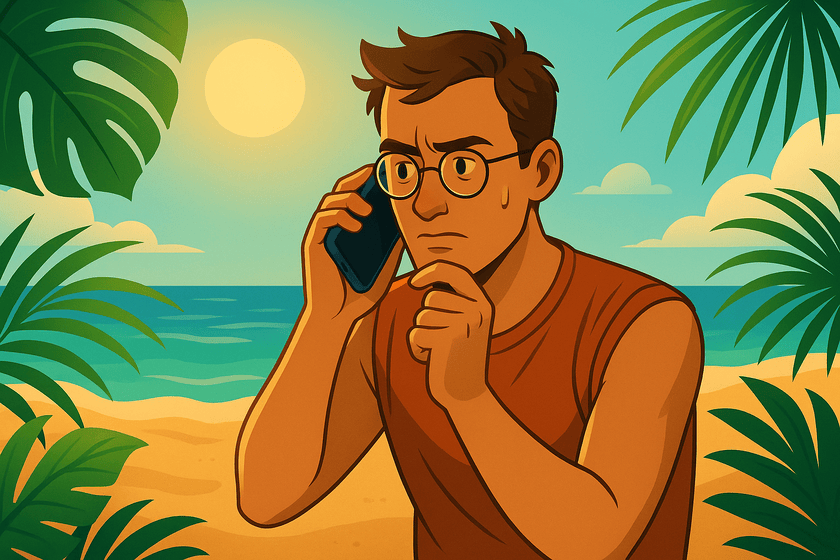

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [49]:
titanic_df = pd.read_csv(base_path, index_col='PassengerId')

In [50]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


In [51]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [52]:
print(titanic_df.head())

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Cabin Embarked  
PassengerId                                                          
1                1      0         A/5 21171   7.2500   NaN        S

#1. Czyszczenie danych

In [53]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,98
Cabin,687


Kolumny ***Ticket*** i ***Name*** nie są istotne w kontekście zadania. Usunę ich, ale przed tym wyciągnę z ***Name*** tytuł (Miss itd.) do innej kolumny, którą póżniej też usunę. Ten tytuł będzie potrzebny do uzupełnienia ***Age*** Kolumna ***Cabin*** ma duże braki, przez co nie nadaje się do wyciągnięcia wniosków, też ją usułam.

In [54]:
titanic_df['Title'] = titanic_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print(titanic_df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1465/729195844.py:1: SyntaxWarning: invalid escape sequence '\.'
  titanic_df['Title'] = titanic_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Rzadkie tytuły wrzuce do jednej kiszeni.

In [56]:
rare_title = ['Dr', 'Rev', 'Col', 'Mlle', 'Major', 'Ms', 'Mme', 'Don', 'Lady', 'Sir', 'Capt', 'Countess', 'Jonkheer']
titanic_df['Title'] = titanic_df['Title'].replace(rare_title, 'Other')
print(titanic_df['Title'].value_counts())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      27
Name: count, dtype: int64


In [57]:
titanic_df.drop(columns=['Cabin', 'Ticket', 'Name'], inplace=True)

In [58]:
print(titanic_df.describe(include='all'))

          Survived      Pclass   Sex         Age       SibSp       Parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008    0.381594   
std       0.486592    0.836071   NaN   14.526497    1.102743    0.806057   
min       0.000000    1.000000   NaN    0.420000    0.000000    0.000000   
25%       0.000000    2.000000   NaN   20.125000    0.000000    0.000000   
50%       0.000000    3.000000   NaN   28.000000    0.000000    0.000000   
75%       1.000000    3.000000   NaN   38.000000    1.000000    0.000000   
max       1.000000    3.000000   NaN   80.000000    8.000000    6.000000   

              Fare Embarked Title  
count   793.000000      889   891  
unique         

In [59]:
print(titanic_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      793 non-null    float64
 7   Embarked  889 non-null    object 
 8   Title     891 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 69.6+ KB
None


Typy danych są odpowiednie do znaczenia kolumn

In [60]:
titanic_df['Embarked']=titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

Uzupełniam kolumnę ***Embarked*** modą, ponieważ brakuje tylko 2 wartości

In [61]:
#Funkcja z pliku EDA_sciaga.ipynb
def plot_numeric_histogram(df, column_name):
    """
    Plots a histogram for the specified column in the DataFrame,
    and adds vertical lines for the mean and median.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the column to plot.
    Returns:
        None. Displays the histogram.
    """

    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [62]:
#Funkcja z pliku EDA_sciaga.ipynb
def plot_categorical_column(df, column_name):
    """
    Plots a bar chart for the specified categorical column.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """

    # count occurrences of each category
    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

Sprawdzam rozkład ceny biletów, aby wybrać, czym wypełnić brakujące dane: średnią czy medianą

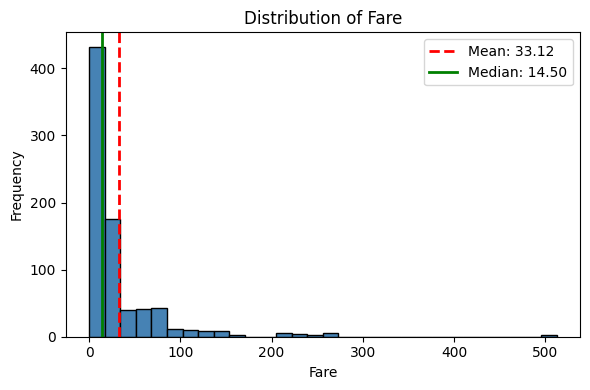

In [63]:
plot_numeric_histogram(titanic_df, 'Fare')

Rozkład jest asymetryczny więc wypełniam medianą

In [64]:
titanic_df['Fare']=titanic_df['Fare'].fillna(titanic_df['Fare'].median())

Kolumnę ***Age*** uzupełniam na podstawie mediany zależnej od kolumn ***Title*** i ***Pclass***.

In [65]:
titanic_df['Age'] = titanic_df.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

In [66]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Title,0


Usułam kolumnę ***Title***, ponieważ nie sądzę, że jest potrzebna w dalszej analizie.

In [67]:
titanic_df.drop(columns=['Title'], inplace=True)

#2. Dadawanie kolumn
Dodaję nowe kolumny: Family_size - liczba członków rodziny na pokładzie (1 oznacza, że pasażer jest sam na pokładzie) i Age_group - grupa wiekowa do której należy pasażer (dziecko, dorosły i senior).

In [68]:
titanic_df['Family_size']=titanic_df['SibSp']+titanic_df['Parch']+1

def AgeGroup(age):
  if age<18:
    return "Child"
  elif age>60:
    return "Senior"
  else:
    return "Adult"

titanic_df["Age_group"]=titanic_df["Age"].apply(AgeGroup)

In [69]:
print(titanic_df.head())

             Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  \
PassengerId                                                                   
1                   0       3    male  22.0      1      0   7.2500        S   
2                   1       1  female  38.0      1      0  71.2833        C   
3                   1       3  female  26.0      0      0   7.9250        S   
4                   1       1  female  35.0      1      0  53.1000        S   
5                   0       3    male  35.0      0      0   8.0500        S   

             Family_size Age_group  
PassengerId                         
1                      2     Adult  
2                      2     Adult  
3                      1     Adult  
4                      2     Adult  
5                      1     Adult  


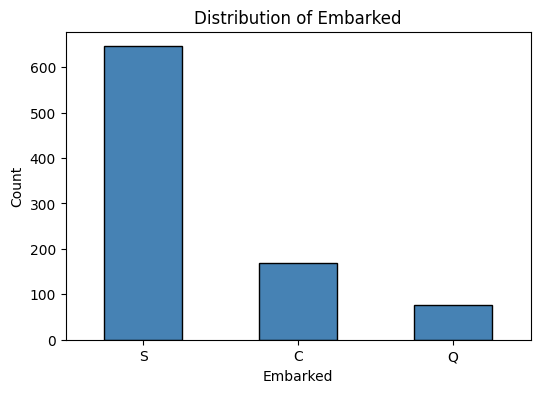

In [70]:
plot_categorical_column(titanic_df, 'Embarked')

# 3. Kodowanie


*   ***Sex*** zakoduje za pomocą one-hot binary encoding, ponieważ mamy tylko dwie kategorie
*   ***Age_group*** zakoduje za pomocą orginal encoding zgodnie z ich kolejnością
* ***Embarked*** zakoduje za pomocą one-hot encoding


In [81]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 1, 'female': 0}) #Binary encoding

mapping = {
    'Child': 0,
    'Adult': 1,
    'Senior': 2
}

titanic_df['Age_group'] = titanic_df['Age_group'].map(mapping) #Ordinal encoding
titanic_df = pd.get_dummies(data=titanic_df, prefix=['Embarked'], columns=['Embarked'], dtype=np.int32) #One-hot encoding

In [82]:
print(titanic_df.head())

             Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Family_size  \
PassengerId                                                                    
1                   0       3    1  22.0      1      0   7.2500            2   
2                   1       1    0  38.0      1      0  71.2833            2   
3                   1       3    0  26.0      0      0   7.9250            1   
4                   1       1    0  35.0      1      0  53.1000            2   
5                   0       3    1  35.0      0      0   8.0500            1   

             Age_group  Embarked_C  Embarked_Q  Embarked_S  
PassengerId                                                 
1                    1           0           0           1  
2                    1           1           0           0  
3                    1           0           0           1  
4                    1           0           0           1  
5                    1           0           0           1  


# 4. Wizualizacja

In [71]:
#Funkcja z pliku EDA_sciaga.ipynb
def boxplot(df, column_name):
    """
    Displays a boxplot of the choosen column to show its distribution.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='lightgreen') # as you can see, you can use sns and plt at the same time
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)

    plt.show()

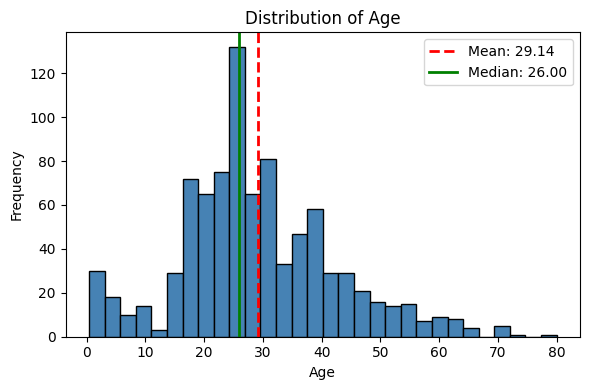

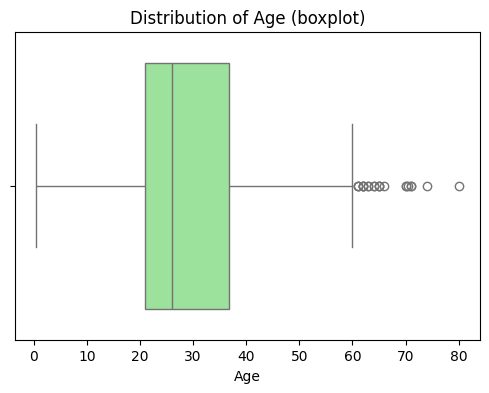

In [72]:
plot_numeric_histogram(titanic_df, 'Age')
boxplot(titanic_df, 'Age')

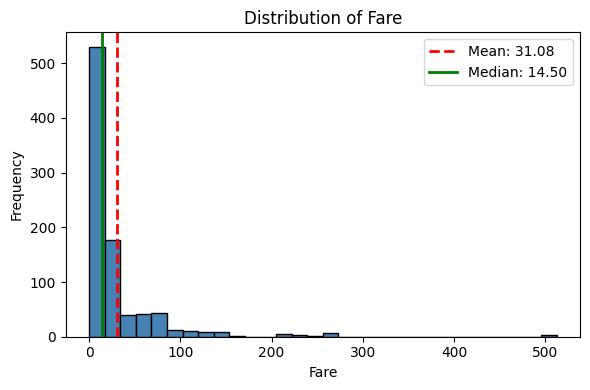

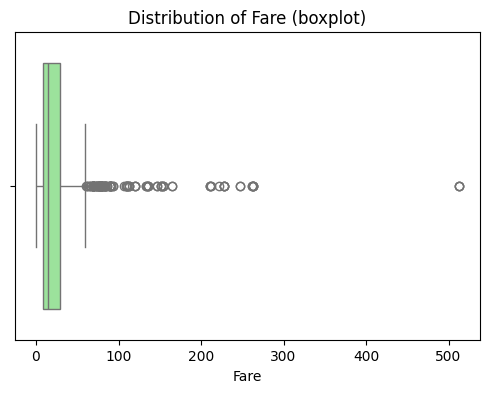

In [73]:
plot_numeric_histogram(titanic_df, 'Fare')
boxplot(titanic_df, 'Fare')

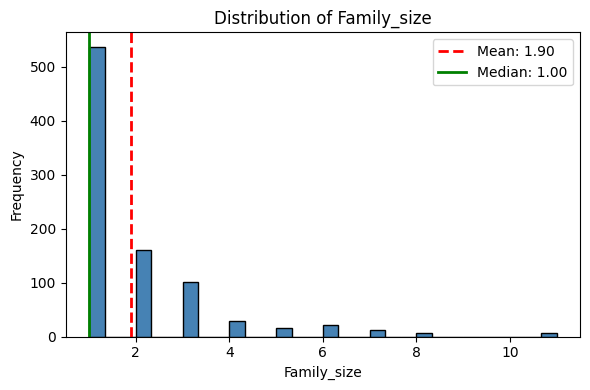

In [74]:
plot_numeric_histogram(titanic_df, 'Family_size')

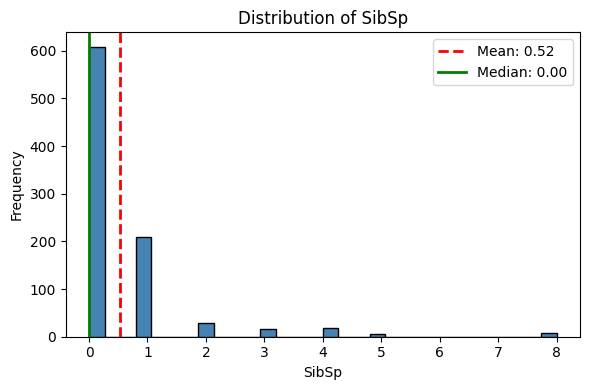

In [75]:
plot_numeric_histogram(titanic_df, 'SibSp')

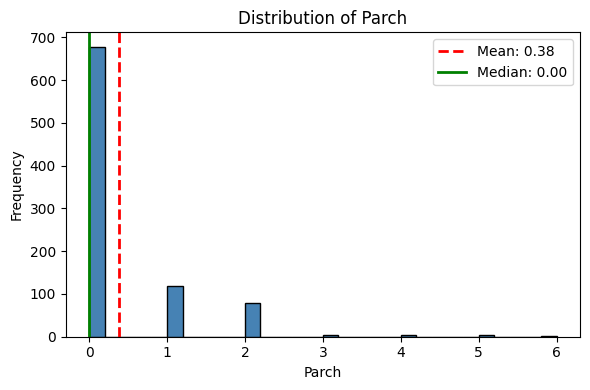

In [76]:
plot_numeric_histogram(titanic_df, 'Parch')

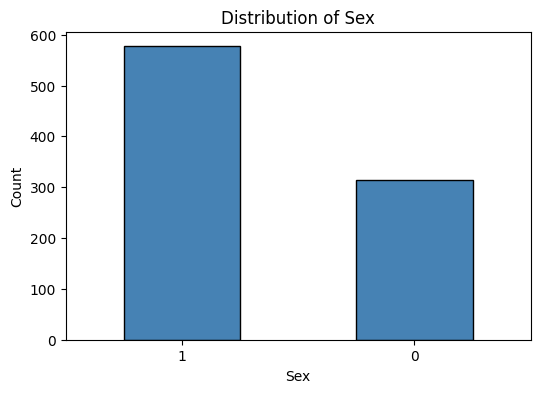

In [83]:
plot_categorical_column(titanic_df, 'Sex')

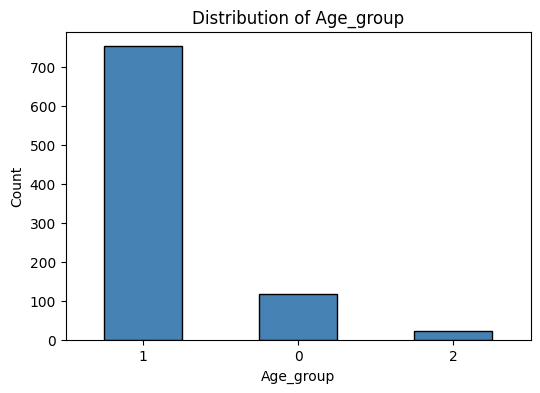

In [84]:
plot_categorical_column(titanic_df, 'Age_group')

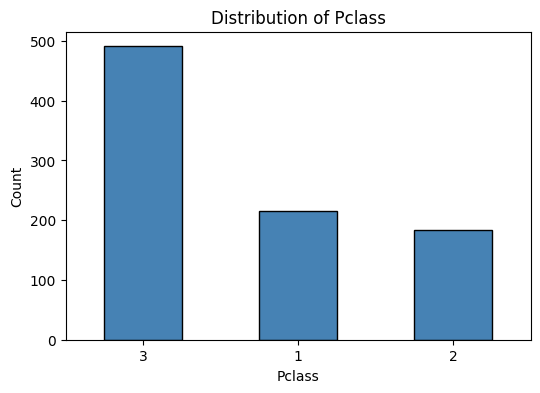

In [85]:
plot_categorical_column(titanic_df, 'Pclass')

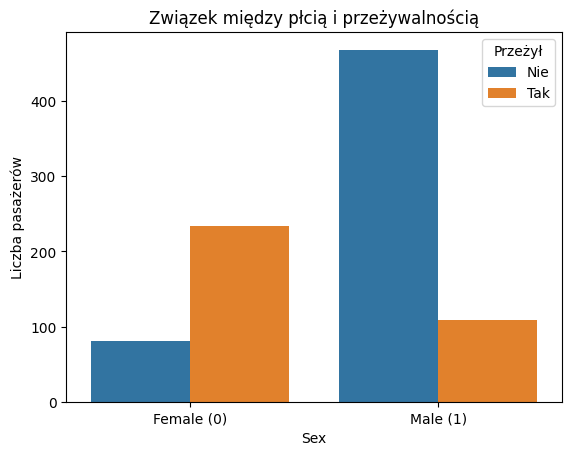

In [86]:
plt.figure()
sns.countplot(data=titanic_df, x='Sex', hue='Survived')
plt.title('Związek między płcią i przeżywalnością')
plt.xticks(ticks=[0, 1], labels=['Female (0)', 'Male (1)'])
plt.ylabel('Liczba pasażerów')
plt.legend(title='Przeżył', labels=['Nie', 'Tak'])
plt.show()

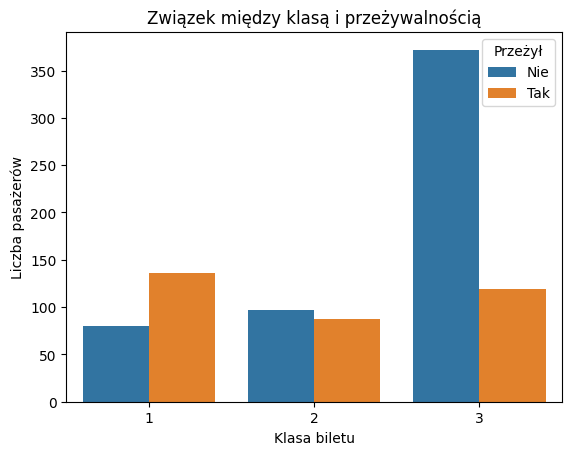

In [87]:
plt.figure()
sns.countplot(data=titanic_df, x='Pclass', hue='Survived')
plt.title('Związek między klasą i przeżywalnością')
plt.xlabel('Klasa biletu')
plt.ylabel('Liczba pasażerów')
plt.legend(title='Przeżył', labels=['Nie', 'Tak'])
plt.show()

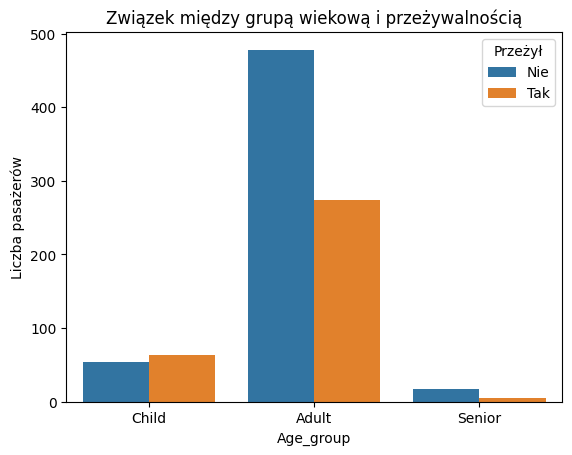

In [88]:
plt.figure()
sns.countplot(data=titanic_df, x='Age_group', hue='Survived')
plt.title('Związek między grupą wiekową i przeżywalnością')
plt.xticks(ticks=[0, 1, 2], labels=['Child', 'Adult', 'Senior'])
plt.ylabel('Liczba pasażerów')
plt.legend(title='Przeżył', labels=['Nie', 'Tak'])
plt.show()

In [89]:
#Funkcja z pliku EDA_sciaga.ipynb
def plot_correlation_matrix(df):
    """
    Plots a heatmap showing the correlation matrix for numeric columns in the DataFrame.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing numeric data.
    Returns:
        None. Displays the correlation heatmap.
    """
    # compute correlation matrix only for numeric columns
    corr = df.corr(numeric_only=True)

    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

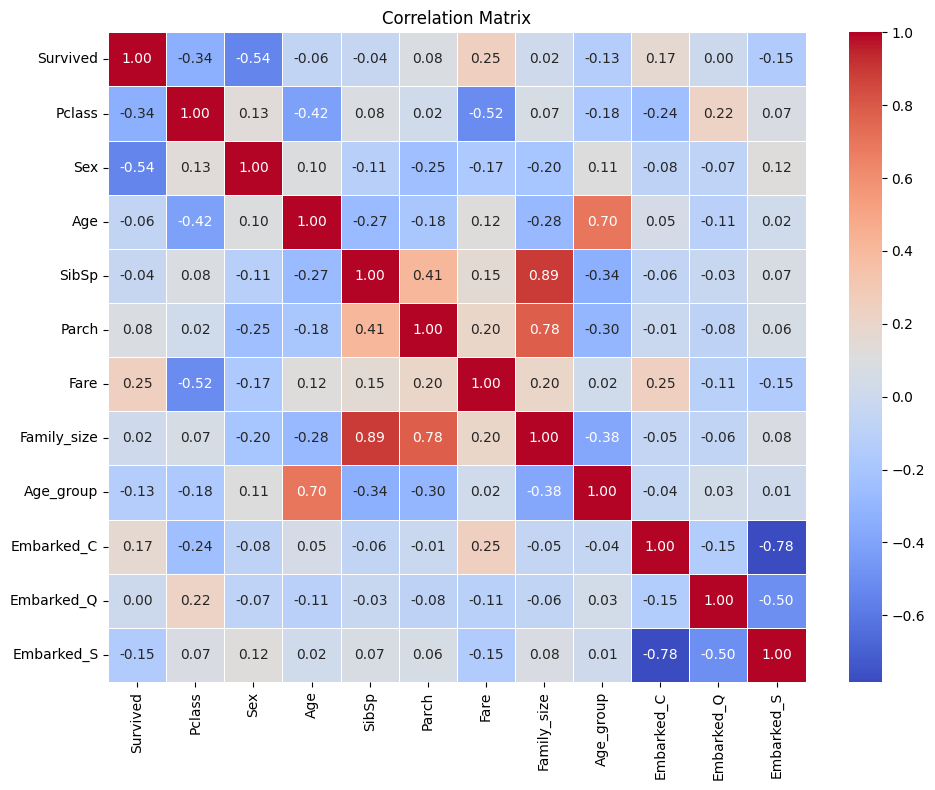

In [90]:
plot_correlation_matrix(titanic_df)

*  Outliery występują, jak i dla danych numerycznych tak i dla kategorycznych. Najwięcej ich jest dla ***Fare***, należałoby tą kolumnę przeskalować, myślę, że najlepiej pasuje tutaj skalowanie logaretmiczne. Natomiast, co robić z danymi dla, których skrajnych wartoci jest mało to nie wiem. Czy podać też jakiemuś skalowaniu, czy zostawić w takiej postaci, bo są to wartości, które mogły wystąpić, więc nie są błędem.
*  Jest zależność pomiędzy wiekiem, płcią, klasą podrózy, a przeżywalnością. Kobiety i dzieci mają większe szanse na przeżycie, tak samo większe szanse mają ci, którzy są w 1 lub 2 klasie.

In [91]:
titanic_df.to_csv('titanic_f.csv')